# Model Training


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import cv2


In [16]:
import os

train_dir = 'C:/Users/ACER/Desktop/My Code/Micro CNN/crack_detection/train_data'
test_dir = 'C:/Users/ACER/Desktop/My Code/Micro CNN/crack_detection/test_data'

if not os.path.exists(train_dir):
    print("Train directory does not exist.")
else:
    print("Train directory exists.")

if not os.path.exists(test_dir):
    print("Test directory does not exist.")
else:
    print("Test directory exists.")


Train directory exists.
Test directory exists.


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Setup
train_datagen = ImageDataGenerator(rescale=1./255)


# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

# Limit to 1000 images
train_generator.samples = 1000
train_generator._set_index_array()


test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 59999 images belonging to 2 classes.
Found 9997 images belonging to 2 classes.


In [17]:
# Limit to 10,000 images
train_generator.samples = min(train_generator.samples, 1000)
train_generator._set_index_array()

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 9997 images belonging to 2 classes.


In [5]:
# Define CNN model
model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(512, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


In [6]:
# Compile the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [9]:
# Train the model
history = model.fit(
    train_generator,
    epochs=3,
    validation_data=test_generator
)


Epoch 1/3
1875/1875 [==============================] - 5293s 3s/step - loss: 0.1472 - accuracy: 0.9477 - val_loss: 0.0350 - val_accuracy: 0.9893
Epoch 2/3
1875/1875 [==============================] - 5574s 3s/step - loss: 0.0898 - accuracy: 0.9702 - val_loss: 0.0604 - val_accuracy: 0.9802
Epoch 3/3
1875/1875 [==============================] - 5274s 3s/step - loss: 0.0695 - accuracy: 0.9780 - val_loss: 0.0637 - val_accuracy: 0.9771


In [10]:
# Save the model
model.save('crack_detection_model.h5')
print(" Model saved as 'crack_detection_model.h5'")


c:\Users\ACER\Desktop\My Code\Micro CNN\model\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


 Model saved as 'crack_detection_model.h5'


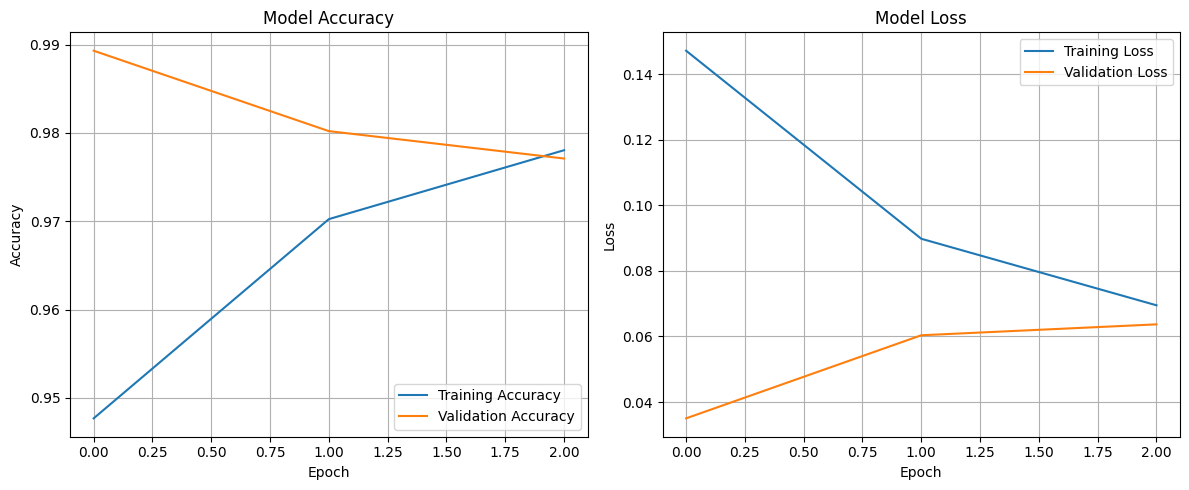

In [11]:
# Plot training history
def plot_train_test_curve(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_train_test_curve(history)

In [12]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.2f}")


313/313 [==============================] - 160s 512ms/step - loss: 0.0637 - accuracy: 0.9771
Test accuracy: 0.98


313/313 [==============================] - 163s 520ms/step


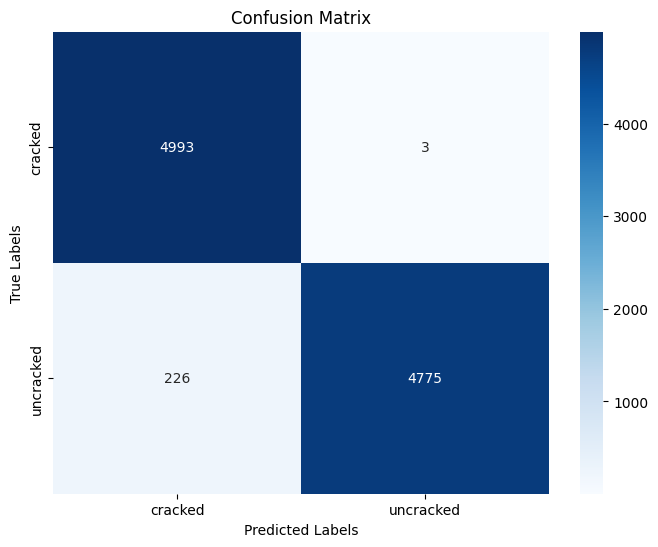

In [13]:
# Predict the test set labels
Y_pred = model.predict(test_generator)
y_pred = (Y_pred > 0.5).astype(int).flatten()

# Get the true labels from the test generator
true_labels = test_generator.classes
class_names = ['cracked', 'uncracked']

# Confusion matrix
conf_matrix = confusion_matrix(true_labels, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [14]:
# Classification report
print("📄 Classification Report:\n", classification_report(true_labels, y_pred, target_names=class_names))


📄 Classification Report:
               precision    recall  f1-score   support

     cracked       0.96      1.00      0.98      4996
   uncracked       1.00      0.95      0.98      5001

    accuracy                           0.98      9997
   macro avg       0.98      0.98      0.98      9997
weighted avg       0.98      0.98      0.98      9997

